In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from water_sim_basic import WaterSim
    
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import time

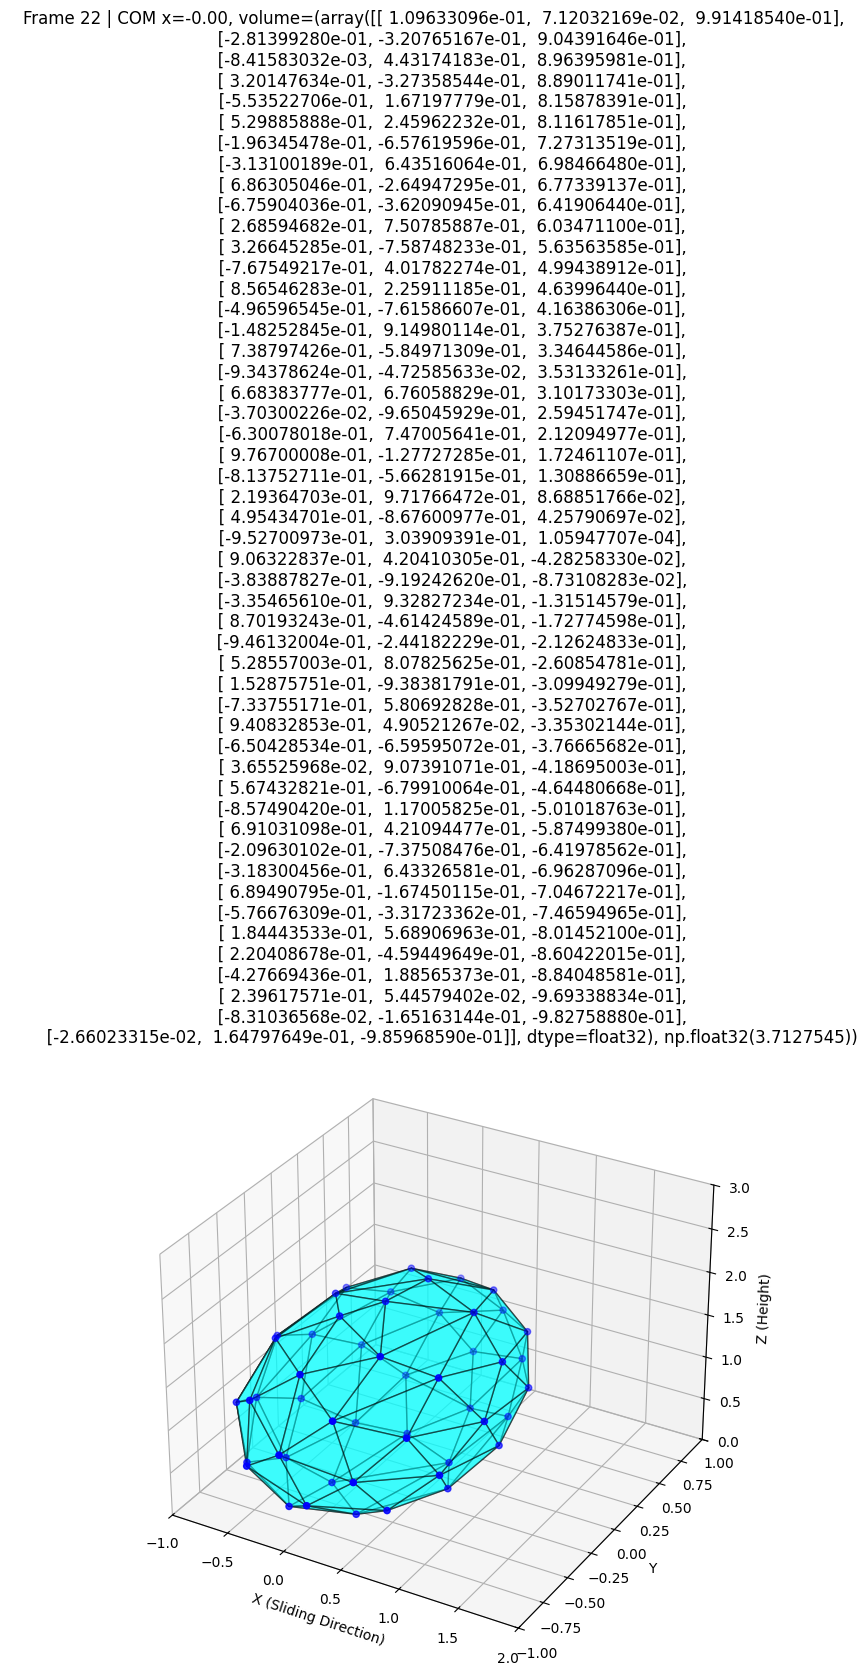

In [ ]:
x, faces, neighbours = WaterSim.generate_polyhedron(n_vertices=50, radius=1.0)
v = np.zeros_like(x)
x += np.array([0.0, 0.0, 1], dtype=np.float32)  # Drop height

sim = WaterSim(
    x, v, faces, neighbours,
    g=np.array([0.0, 0.0, -9.81], dtype=np.float32),  # Tilted so it slides
    gamma=50,
    mu=0.30,
    nu=0.1,
    k_v=20.0,
    boundary_alpha=0.1,
    friction_coeff=0.1,
    density=1.0,
 )

# Simulation settings
dt = 0.008
sub_steps = 8
sub_dt = dt / sub_steps

# Rendering setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
poly = Poly3DCollection(x[faces], alpha=0.5, edgecolor="k", facecolors="cyan")
ax.add_collection3d(poly)
sc = ax.scatter(x[:, 0], x[:, 1], x[:, 2], c="blue", s=20)

ax.set(
    xlim=(-2, 4),
    ylim=(-3, 3),
    zlim=(0, 4),
    xlabel="X (Sliding Direction)",
    ylabel="Y",
    zlabel="Z (Height)",
    title="Real-Time Interactive Water Droplets Simulator",
)

for frame in range(400):
    for _ in range(sub_steps):
        v, x = sim.step_simulation(sub_dt, method="euler", volume_correction_mode="both")

    # Update visual data
    sc._offsets3d = (x[:, 0], x[:, 1], x[:, 2])
    poly.set_verts(x[faces])

    # Keep droplet in view as it slides
    center = x.mean(axis=0)
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 1)
    ax.set_zlim(0.0, 3)
    _, volume = sim.compute_vertex_normals_and_volume(x)
    ax.set_title(f"Frame {frame} | COM x={center[0]:.2f}, volume={volume:.2f}")

    # Notebook-friendly refresh
    display.clear_output(wait=True)
    display.display(fig)
    time.sleep(0.01)

plt.close(fig)